<a href="https://colab.research.google.com/github/RubaEgbaria/Esch-Crowd-Monitoring/blob/master/sensors_fusion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [15]:
# ============================================================
# 0. Mount Google Drive & locate the experiment folder
# ============================================================
from google.colab import drive
drive.mount('/content/drive')

import os, pathlib

# experiment folder in Drive ----
DRIVE_ROOT = "/content/drive/My Drive/Crowd-Density-Monitoring/Code/baseline"
# -------------------------------------------------------

assert os.path.isdir(DRIVE_ROOT), f"Drive path not found: {DRIVE_ROOT}"
print("Drive root:", DRIVE_ROOT)

print("\nContents of Drive root:")
for p in sorted(pathlib.Path(DRIVE_ROOT).rglob("*")):
    if p.is_file():
        size_mb = p.stat().st_size / 1e6
        print(f"  {p.relative_to(DRIVE_ROOT)}  ({size_mb:.1f} MB)")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Drive root: /content/drive/My Drive/Crowd-Density-Monitoring/Code/baseline

Contents of Drive root:
  192.168.137.36_2026-09-08_11-33-52.zip  (132.1 MB)
  detection_counts.json  (0.0 MB)
  lidar_top_view.mp4  (21.0 MB)
  outputs/aligned_camera_yolo_gt.csv  (0.0 MB)
  outputs/aligned_counts.csv  (0.0 MB)
  outputs/best_ensemble_trace.png  (0.1 MB)
  outputs/ensemble_results.csv  (0.0 MB)
  outputs/fusion_demo.mp4  (22.9 MB)
  outputs/lidar_counts.json  (0.2 MB)
  outputs/mae_bar.png  (0.1 MB)
  outputs/results_table.tex  (0.0 MB)
  outputs/roi_check.png  (0.8 MB)
  outputs/timeseries.png  (0.3 MB)
  outputs/yolo_detections.json  (0.2 MB)
  raw-vid.mp4  (13.4 MB)
  yolo11m.pt  (40.7 MB)


In [16]:
# ============================================================
# CONFIG — EDIT THIS BLOCK ONLY
# ============================================================
import os, re, json, zipfile
from datetime import datetime, timezone

# --- Experiment assets (all on Drive) ---
VIDEO_PATH  = f"{DRIVE_ROOT}/raw-vid.mp4"
CAMERA_JSON = f"{DRIVE_ROOT}/detection_counts.json"
LIDAR_ZIP   = f"{DRIVE_ROOT}/192.168.137.36_2026-09-08_11-33-52.zip"
LIDAR_BEV   = f"{DRIVE_ROOT}/lidar_top_view.mp4"

# Outputs: keep them on Drive so they persist between Colab sessions.
OUT_DIR     = f"{DRIVE_ROOT}/outputs"
os.makedirs(OUT_DIR, exist_ok=True)


# ============================================================
# Helpers to auto-detect the LiDAR start time from the .zip
# (metadata.json → inner .pcd filenames → zip filename)
# ============================================================
def _iso_from_epoch(epoch_s):
    return datetime.fromtimestamp(epoch_s, tz=timezone.utc)\
                   .replace(tzinfo=None).isoformat()

def _iso_from_epoch_ms(epoch_ms):
    return _iso_from_epoch(epoch_ms / 1000.0)

def _start_from_metadata(zip_path):
    try:
        with zipfile.ZipFile(zip_path) as zf:
            metas = [n for n in zf.namelist()
                     if n.lower().endswith(".json") and "meta" in n.lower()]
            if not metas:
                return None, "no metadata.json inside zip"
            with zf.open(metas[0]) as f:
                meta = json.load(f)
    except Exception as e:
        return None, f"metadata read failed: {e}"

    for key in ("recording_start_time", "start_time",
                "recording_start", "created_at", "timestamp"):
        if key in meta:
            v = meta[key]
            if isinstance(v, (int, float)):
                return (_iso_from_epoch_ms(v) if v > 1e12
                        else _iso_from_epoch(v)), f"metadata[{key}]"
            if isinstance(v, str):
                try:
                    dt = datetime.fromisoformat(v.replace("Z", "+00:00"))
                    return dt.replace(tzinfo=None).isoformat(), f"metadata[{key}]"
                except ValueError:
                    pass
    nested = meta.get("recording") or meta.get("session") or {}
    for key in ("start_time", "recording_start_time", "created_at"):
        if key in nested:
            v = nested[key]
            if isinstance(v, (int, float)):
                return (_iso_from_epoch_ms(v) if v > 1e12
                        else _iso_from_epoch(v)), f"metadata.recording[{key}]"
            if isinstance(v, str):
                try:
                    dt = datetime.fromisoformat(v.replace("Z", "+00:00"))
                    return dt.replace(tzinfo=None).isoformat(), \
                           f"metadata.recording[{key}]"
                except ValueError:
                    pass
    return None, "metadata.json has no recognisable start key"

def _start_from_inner_filenames(zip_path):
    try:
        with zipfile.ZipFile(zip_path) as zf:
            names = [n for n in zf.namelist()
                     if n.lower().endswith((".pcd", ".bin", ".ply"))]
    except Exception as e:
        return None, f"inner name read failed: {e}"
    if not names:
        return None, "no point-cloud members inside zip"

    def extract_epoch(name):
        stem = os.path.splitext(os.path.basename(name))[0]
        digits = re.findall(r"\d{10,19}", stem)
        if not digits:
            return None
        d = digits[-1]
        if len(d) >= 16: return int(d) / 1e9, "ns"
        if len(d) >= 13: return int(d) / 1e3, "ms"
        return int(d), "s"

    cands = [(n, extract_epoch(n)) for n in names]
    cands = [(n, ep) for n, ep in cands if ep is not None]
    if not cands:
        return None, "no epoch-style timestamp in inner filenames"
    cands.sort(key=lambda x: x[1][0])
    epoch, unit = cands[0][1]
    return _iso_from_epoch(epoch), f"inner filename ({unit})"

def _start_from_zip_filename(zip_path):
    base = os.path.splitext(os.path.basename(zip_path))[0]
    m = re.search(r"(\d{4})[-_](\d{2})[-_](\d{2})[T_ ]"
                  r"(\d{2})[-:](\d{2})[-:](\d{2})(?:[._-](\d{1,3}))?", base)
    if m:
        y, mo, d, h, mi, s, ms = m.groups()
        ms = (ms or "0").ljust(3, "0")
        return f"{y}-{mo}-{d}T{h}:{mi}:{s}.{ms}", "zip filename (ISO-ish)"
    m = re.search(r"(\d{4})(\d{2})(\d{2})[_-]?(\d{2})(\d{2})(\d{2})", base)
    if m:
        y, mo, d, h, mi, s = m.groups()
        return f"{y}-{mo}-{d}T{h}:{mi}:{s}.000", "zip filename (compact)"
    m = re.search(r"(\d{10,13})", base)
    if m:
        d = m.group(1)
        if len(d) >= 13:
            return _iso_from_epoch_ms(int(d)), "zip filename (ms epoch)"
        return _iso_from_epoch(int(d)), "zip filename (s epoch)"
    return None, "zip filename has no recognisable timestamp"

def detect_lidar_start_iso(zip_path):
    for name, fn in [("metadata.json",   _start_from_metadata),
                     ("inner filenames", _start_from_inner_filenames),
                     ("zip filename",    _start_from_zip_filename)]:
        iso, why = fn(zip_path)
        if iso:
            print(f"[LiDAR time] resolved from {name}: {iso}  ({why})")
            return iso
        print(f"[LiDAR time] {name}: {why}")
    raise RuntimeError("Could not detect LiDAR start time from zip. "
                       "Set CONFIG['lidar_start_iso'] manually.")


CONFIG = {
    # Camera
    "video_path":        VIDEO_PATH,
    "camera_json":       CAMERA_JSON,
    "video_start_iso":   "2026-09-10T13:56:18",

    # LiDAR (Blickfeld Qb2) — start time auto-detected from zip
    "lidar_zip":         LIDAR_ZIP,
    "lidar_start_iso":   None,        # filled in below
    "lidar_points_topic":"point_cloud",

    # Manual ground truth (video-time seconds, "T" = video duration)
    "manual_gt_segments": [
        (0,     5.0,   5),
        (5.0,   "T-4", 6),
        ("T-4", "T",   5),
    ],

    # ROI on the floor plane (metres, camera-frame x=right, y=forward)
    "roi_floor_xy": [
        [-2.0, 1.0], [2.0, 1.0], [2.0, 6.0], [-2.0, 6.0]
    ],

    # 4-point floor -> pixel homography (measure these in the lab)
    "floor_calib_xy": [[-2.0, 1.0], [2.0, 1.0], [2.0, 6.0], [-2.0, 6.0]],
    "floor_calib_uv": [[320, 480], [960, 480], [1100, 100], [180, 100]],
    "calib_frame_idx": 60,


    # YOLO
    "yolo_model":  "yolo11m.pt",
    "yolo_conf":   0.25,
    "yolo_imgsz":  640,

    # LiDAR (same pipeline as Qb2_people_counting.ipynb)
    "bg_dist":            0.15,   # background subtraction radius [m]
    "min_h":              0.10,   # min height above floor [m]
    "dbscan_eps":         0.10,
    "dbscan_min_samples": 5,
    "w_range":            (0.15, 1.05),
    "d_range":            (0.15, 1.05),
    "top_range":          (0.9, 2.3),
    "single_person_span": 0.65,
    "track_max_dist":     0.6,
    "track_min_hits":     3,
    "track_max_miss":     4,
    "smooth_window":      8,      # ~1 s at 7.8 Hz

    # Time grid & CV
    "grid_hz":    10,
    "cv_folds":   5,

    # Outputs
    "out_dir":    OUT_DIR,
}

# ----- Auto-detect the LiDAR start time -----
try:
    CONFIG["lidar_start_iso"] = detect_lidar_start_iso(CONFIG["lidar_zip"])
except FileNotFoundError:
    print("[LiDAR time] zip not found on Drive yet — "
          "keeping placeholder. Fix the path and re-run this cell.")
    CONFIG["lidar_start_iso"] = "2026-09-10T13:56:20.300"
except Exception as e:
    print(f"[LiDAR time] auto-detect failed ({e}); "
          "using manual fallback")
    CONFIG["lidar_start_iso"] = "2026-09-10T13:56:20.300"

print("\nCONFIG ready. Outputs →", CONFIG["out_dir"])
print("LiDAR start :", CONFIG["lidar_start_iso"])
print("Video start :", CONFIG["video_start_iso"])

[LiDAR time] metadata.json: metadata.json has no recognisable start key
[LiDAR time] inner filenames: no epoch-style timestamp in inner filenames
[LiDAR time] resolved from zip filename: 2026-09-08T11:33:52.000  (zip filename (ISO-ish))

CONFIG ready. Outputs → /content/drive/My Drive/Crowd-Density-Monitoring/Code/baseline/outputs
LiDAR start : 2026-09-08T11:33:52.000
Video start : 2026-09-10T13:56:18


In [17]:
# ============================================================
# Imports & environment setup
# ============================================================
import os, sys, json, re, zipfile, shutil, subprocess, warnings, pathlib
from datetime import datetime, timezone
from collections import Counter

warnings.filterwarnings("ignore")

# --- Core scientific stack ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.path import Path as MplPath

# --- Computer vision ---
import cv2

# --- Point cloud / LiDAR (Blickfeld Qb2 .pb frames) ---
try:
    from blickfeld_qb2.core_processing.data import Frame
except ImportError:
    print("Installing blickfeld_qb2 …")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "blickfeld_qb2", "scipy"])
    from blickfeld_qb2.core_processing.data import Frame
from scipy.spatial import cKDTree
from scipy.spatial.transform import Rotation as R
import glob, base64, tempfile

# --- YOLO ---
try:
    from ultralytics import YOLO
except ImportError:
    print("Installing ultralytics …")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "ultralytics"])
    from ultralytics import YOLO

# --- scikit-learn ---
try:
    from sklearn.cluster import DBSCAN, KMeans
    from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
    from sklearn.linear_model import LinearRegression
    from sklearn.metrics import mean_absolute_error, mean_squared_error
    from sklearn.model_selection import KFold
except ImportError:
    print("Installing scikit-learn …")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "scikit-learn"])
    from sklearn.cluster import DBSCAN, KMeans
    from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
    from sklearn.linear_model import LinearRegression
    from sklearn.metrics import mean_absolute_error, mean_squared_error
    from sklearn.model_selection import KFold

# --- SciPy (for nnls weight fitting in the ensemble cell) ---
try:
    from scipy.optimize import nnls
    from scipy.stats import mode
except ImportError:
    print("Installing scipy …")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "scipy"])
    from scipy.optimize import nnls
    from scipy.stats import mode

np.random.seed(0)
print("Imports OK")
print(f"  python  : {sys.version.split()[0]}")
print(f"  numpy   : {np.__version__}")
print(f"  pandas  : {pd.__version__}")
print(f"  opencv  : {cv2.__version__}")

Imports OK
  python  : 3.13.15
  numpy   : 2.1.3
  pandas  : 2.2.3
  opencv  : 5.0.0


In [18]:
# ============================================================
# Qb2 recording loaders
# ============================================================
def find_recording(root):
    if root.lower().endswith(".zip"):
        tmp = tempfile.mkdtemp(prefix="qb2rec_")
        with zipfile.ZipFile(root) as z:
            z.extractall(tmp)
        root = tmp
    frames = sorted(glob.glob(os.path.join(root, "**", "frame_*.pb"), recursive=True))
    ref    = glob.glob(os.path.join(root, "**", "perceptPipelineReferenceFrame.json"), recursive=True)
    zones  = glob.glob(os.path.join(root, "**", "perceptPipelineZones.json"), recursive=True)
    ds     = glob.glob(os.path.join(root, "**", "perceptPipelineDataSource.json"), recursive=True)
    assert frames, "no frame_*.pb found"
    assert ref and zones and ds, "metadata json missing"
    return frames, ref[0], zones[0], ds[0]

def load_frame_pb(path):
    fr = Frame().parse(open(path, "rb").read())
    xyz = np.asarray(fr.binary.cartesian, dtype=np.float32).reshape(-1, 3)
    return fr.id, fr.timestamp, xyz

def load_reference(path):
    r = json.load(open(path))
    return np.frombuffer(base64.b64decode(r["binary"]["cartesian"]), dtype=np.float32).reshape(-1, 3)


In [20]:
# ============================================================
# 2.1 Load video metadata
# ============================================================

cap = cv2.VideoCapture(CONFIG["video_path"])
fps          = cap.get(cv2.CAP_PROP_FPS)
total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
T            = total_frames / fps
cap.release()
print(f"Video: {fps:.3f} fps | {total_frames} frames | {T:.2f} s")

# ============================================================
# 2.2 YOLO pedestrian detection (every frame, keep boxes)
# ============================================================
model = YOLO(CONFIG["yolo_model"])
cap = cv2.VideoCapture(CONFIG["video_path"])

yolo_records = []   # list of dicts: t, count, detections[{box,conf,cx,cy}]
frame_idx = 0
while True:
    ok, frame = cap.read()
    if not ok:
        break
    rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    res = model(rgb, conf=CONFIG["yolo_conf"],
                imgsz=CONFIG["yolo_imgsz"], verbose=False)[0]
    dets = []
    for b in res.boxes:
        if res.names[int(b.cls)] != "person":
            continue
        x1, y1, x2, y2 = b.xyxy[0].tolist()
        dets.append({
            "box": [round(x1), round(y1), round(x2), round(y2)],
            "conf": round(float(b.conf), 3),
            "cx": round((x1+x2)/2), "cy": round((y1+y2)/2),
        })
    yolo_records.append({
        "frame": frame_idx,
        "t": frame_idx / fps,
        "count": len(dets),
        "detections": dets,
    })
    if frame_idx % 50 == 0:
        print(f"  YOLO frame {frame_idx}/{total_frames}: {len(dets)} person(s)")
    frame_idx += 1
cap.release()
print(f"YOLO done: {len(yolo_records)} frames")

with open(f"{CONFIG['out_dir']}/yolo_detections.json", "w") as f:
    json.dump(yolo_records, f)
print("  saved yolo_detections.json")

# ============================================================
# 2.3 Camera-app output (counts per frame or per second)
# ============================================================
with open(CONFIG["camera_json"]) as f:
    cam_json = json.load(f)

keys = list(cam_json["per_frame"].keys())
print(f"Camera JSON: {len(keys)} entries, first keys = {keys[:5]}")

# Auto-detect unit: seconds or frames
max_key = max(int(k) for k in keys)
if max_key <= T + 2:                 # keys are seconds
    unit = "seconds"
    cam_records = [{"t": float(k), "count": int(v)}
                   for k, v in cam_json["per_frame"].items()]
else:                                # keys are frames
    unit = "frames"
    cam_records = [{"t": int(k) / fps, "count": int(v)}
                   for k, v in cam_json["per_frame"].items()]
cam_records.sort(key=lambda r: r["t"])
print(f"  detected unit: {unit}, t-range = "
      f"{cam_records[0]['t']:.2f}..{cam_records[-1]['t']:.2f} s")

# ============================================================
# 2.4 Manual ground truth on the master grid
# ============================================================
def resolve_segments(segs, T):
    out = []
    for s, e, c in segs:
        s = T if s == "T" else (T - float(s.split("-")[1]) if isinstance(s, str) else float(s))
        e = T if e == "T" else (T - float(e.split("-")[1]) if isinstance(e, str) else float(e))
        out.append((s, e, c))
    return out

gt_segments = resolve_segments(CONFIG["manual_gt_segments"], T)
print("Manual GT segments:", gt_segments)

GRID_HZ = CONFIG["grid_hz"]
t_grid  = np.arange(0, T, 1.0 / GRID_HZ)

def sample_gt(t_grid, segs):
    y = np.zeros_like(t_grid, dtype=float)
    for s, e, c in segs:
        y[(t_grid >= s) & (t_grid < e)] = c
    return y

manual_gt = sample_gt(t_grid, gt_segments)

# ============================================================
# 2.5 Resample camera & YOLO onto the grid
# ============================================================
def resample_counts(records, t_grid):
    ts = np.array([r["t"] for r in records])
    cs = np.array([r["count"] for r in records], dtype=float)
    idx = np.clip(np.searchsorted(ts, t_grid), 1, len(ts) - 1)
    return cs[idx]

cam_counts_grid  = resample_counts(cam_records,  t_grid)
yolo_counts_grid = resample_counts(yolo_records, t_grid)

df = pd.DataFrame({
    "t":         t_grid,
    "manual_gt": manual_gt,
    "camera":    cam_counts_grid,
    "yolo":      yolo_counts_grid,
})
df.to_csv(f"{CONFIG['out_dir']}/aligned_camera_yolo_gt.csv", index=False)
print(df.head())

Video: 10.520 fps | 454 frames | 43.16 s
  YOLO frame 0/454: 0 person(s)
  YOLO frame 50/454: 5 person(s)
  YOLO frame 100/454: 6 person(s)
  YOLO frame 150/454: 6 person(s)
  YOLO frame 200/454: 5 person(s)
  YOLO frame 250/454: 4 person(s)
  YOLO frame 300/454: 6 person(s)
  YOLO frame 350/454: 5 person(s)
  YOLO frame 400/454: 6 person(s)
  YOLO frame 450/454: 6 person(s)
YOLO done: 454 frames


FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/My Drive/Crowd-Density-Monitoring/Code/baseline/outputs/yolo_detections.json'

In [21]:
# os.makedirs(CONFIG["out_dir"], exist_ok=True)
# with open(f"{CONFIG['out_dir']}/yolo_detections.json", "w") as f:
#     json.dump(yolo_records, f)

Using frame 60 for ROI overlay (mean brightness = 120.5)


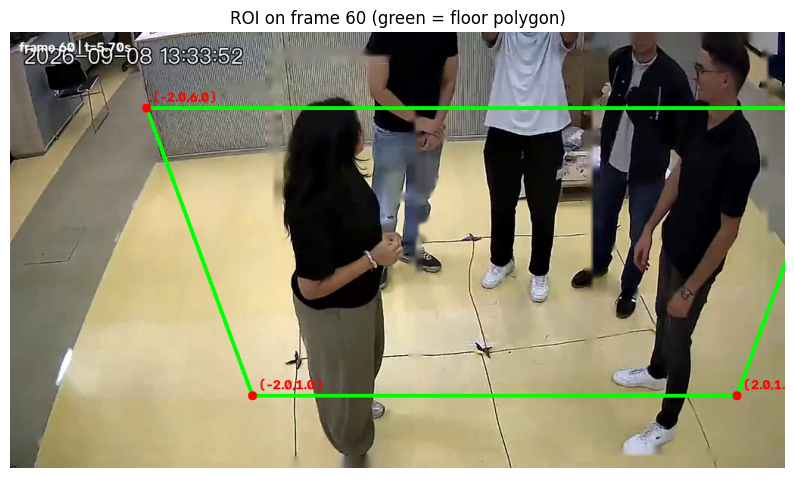

In [22]:
# ============================================================
# 3.1 Build homography from 4 floor correspondences
# ============================================================
src = np.array(CONFIG["floor_calib_xy"], dtype=np.float32)   # floor metres
dst = np.array(CONFIG["floor_calib_uv"], dtype=np.float32)   # pixels
H, _ = cv2.findHomography(src, dst)

def floor_xy_to_px(xy):
    pts = np.array(xy, dtype=np.float32).reshape(-1, 1, 2)
    return cv2.perspectiveTransform(pts, H).reshape(-1, 2)

roi_px = floor_xy_to_px(CONFIG["roi_floor_xy"])

# ============================================================
# 3.2 Grab a well-exposed reference frame
# ============================================================
def grab_reference_frame(video_path, preferred_idx=60,
                         min_mean_brightness=30, search_window=60):
    """
    Return (frame_idx, frame):
      - Try preferred_idx first.
      - If its mean brightness < min_mean_brightness, scan +-search_window
        for a brighter frame.
      - Never returns a frame with mean brightness below min_mean_brightness
        unless the whole window is dark.
    """
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        cap.release()
        raise IOError(f"Cannot open {video_path}")

    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    preferred_idx = int(np.clip(preferred_idx, 0, total - 1))

    def read_at(idx):
        cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
        ok, f = cap.read()
        if not ok:
            return None
        return f

    frame = read_at(preferred_idx)
    if frame is not None:
        b = float(frame.mean())
        if b >= min_mean_brightness:
            cap.release()
            return preferred_idx, frame
        print(f"[ref frame] frame {preferred_idx} is dark (mean={b:.1f}); searching …")
    else:
        b = -1

    # Scan outward from preferred_idx
    best_idx, best_frame, best_b = preferred_idx, frame, b
    for off in range(1, search_window + 1):
        for cand in (preferred_idx + off, preferred_idx - off):
            if 0 <= cand < total:
                f = read_at(cand)
                if f is None:
                    continue
                cand_b = float(f.mean())
                if cand_b > best_b:
                    best_idx, best_frame, best_b = cand, f, cand_b
                if cand_b >= min_mean_brightness:
                    cap.release()
                    print(f"[ref frame] picked frame {cand} (mean={cand_b:.1f})")
                    return cand, f

    cap.release()
    print(f"[ref frame] WARNING: best found was frame {best_idx} "
          f"(mean={best_b:.1f}). Consider verifying the video.")
    return best_idx, best_frame

calib_frame_idx, frame = grab_reference_frame(
    CONFIG["video_path"],
    preferred_idx=CONFIG.get("calib_frame_idx", 60),
    min_mean_brightness=30,
    search_window=60,
)
print(f"Using frame {calib_frame_idx} for ROI overlay "
      f"(mean brightness = {frame.mean():.1f})")

# ============================================================
# 3.3 Save a visual check
# ============================================================
overlay = frame.copy()
cv2.polylines(overlay, [roi_px.astype(int)], True, (0, 255, 0), 3)
for (u, v), (x, y) in zip(dst, src):
    cv2.circle(overlay, (int(u), int(v)), 6, (0, 0, 255), -1)
    cv2.putText(overlay, f"({x:.1f},{y:.1f})", (int(u) + 8, int(v) - 8),
                cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 0, 255), 2)

# Frame index stamp
cv2.putText(overlay, f"frame {calib_frame_idx} | t={calib_frame_idx/fps:.2f}s",
            (12, 26), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 255), 2)

cv2.imwrite(f"{CONFIG['out_dir']}/roi_check.png", overlay)
plt.figure(figsize=(10, 6))
plt.imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
plt.title(f"ROI on frame {calib_frame_idx} (green = floor polygon)")
plt.axis("off")
plt.show()


In [23]:
# ============================================================
# 4.1 Load the Qb2 recording (frames + background + zone)
# ============================================================
frame_files, ref_path, zones_path, ds_path = find_recording(CONFIG["lidar_zip"])
background = load_reference(ref_path)
print(f"{len(frame_files)} frames, background cloud {len(background)} pts")

# ============================================================
# 4.2 Floor plane (RANSAC on the background) -> floor frame (u, v, h)
# ============================================================
def fit_floor_plane(pts, iters=3000, thresh=0.05, seed=42):
    rng = np.random.default_rng(seed); best = (0, None, None)
    for _ in range(iters):
        p = pts[rng.choice(len(pts), 3, replace=False)]
        n = np.cross(p[1] - p[0], p[2] - p[0]); nl = np.linalg.norm(n)
        if nl < 1e-6:
            continue
        n /= nl; d = -n @ p[0]
        cnt = int((np.abs(pts @ n + d) < thresh).sum())
        if cnt > best[0]:
            best = (cnt, n, d)
    _, n, d = best
    inl = pts[np.abs(pts @ n + d) < thresh]; c = inl.mean(0)
    n = np.linalg.svd(inl - c)[2][2]; d = -n @ c
    if d < 0:
        n, d = -n, -d                          # sensor (origin) is above the floor
    a = np.array([1., 0, 0]) if abs(n[0]) < 0.9 else np.array([0, 1., 0])
    u = np.cross(n, a); u /= np.linalg.norm(u); v = np.cross(n, u)
    return n, d, u, v, best[0] / len(pts)

n_up, d_floor, u_ax, v_ax, floor_frac = fit_floor_plane(background)
print(f"floor plane covers {floor_frac:.0%} of background, sensor height = {d_floor:.2f} m")

def to_floor_frame(xyz):
    return np.column_stack([xyz @ u_ax, xyz @ v_ax, xyz @ n_up + d_floor])

background_f = to_floor_frame(background)
bg_tree = cKDTree(background)

# ============================================================
# 4.3 Occupancy zone from the sensor config
# ============================================================
zones = json.load(open(zones_path))
ds    = json.load(open(ds_path))
mfl   = ds["qb2Setup"]["lidars"][0]["mapFromLidar"]
q, t  = mfl["rotation"], mfl["translation"]
map_from_lidar_R = R.from_quat([q.get("x", 0), q.get("y", 0), q.get("z", 0), q.get("w", 1)])
map_from_lidar_t = np.array([t.get("x", 0), t.get("y", 0), t.get("z", 0)])

zone = zones[0]
zc  = zone["shape"]["pose"]["position"]; zd = zone["shape"]["box"]["dimensions"]
zo  = zone["shape"]["pose"].get("orientation", {})
zone_R = R.from_quat([zo.get("x", 0), zo.get("y", 0), zo.get("z", 0), zo.get("w", 1)])
print(f"zone '{zone['name']}': center ({zc['x']:.2f}, {zc['y']:.2f}) size {zd['x']}x{zd['y']} m")

def in_zone_xy(xyz):
    m = map_from_lidar_R.apply(xyz) + map_from_lidar_t
    local = zone_R.inv().apply(m - [zc["x"], zc["y"], zc.get("z", 0)])
    return (np.abs(local[:, 0]) <= zd["x"] / 2) & (np.abs(local[:, 1]) <= zd["y"] / 2)

# ============================================================
# 4.4 LiDAR timestamps (from the frames) -> video time
# ============================================================
t0_lidar = datetime.fromisoformat(CONFIG["lidar_start_iso"]).replace(tzinfo=timezone.utc).timestamp()
t0_video = datetime.fromisoformat(CONFIG["video_start_iso"]).replace(tzinfo=timezone.utc).timestamp()
offset = t0_lidar - t0_video
if abs(offset) > 60:
    print(f"  WARNING: LiDAR/video start differ by {offset:.0f}s — ignoring, "
          "cross-correlation will align them")
    offset = 0.0

ts_ns = np.array([load_frame_pb(f)[1] for f in frame_files], dtype=np.int64)
lidar_times = (ts_ns - ts_ns[0]) / 1e9 + offset
lidar_rate  = 1.0 / np.median(np.diff(lidar_times))
print(f"LiDAR time range (video-time): {lidar_times[0]:.2f} .. {lidar_times[-1]:.2f} s  "
      f"({lidar_rate:.1f} Hz)")


284 frames, background cloud 7680 pts
floor plane covers 73% of background, sensor height = 2.31 m
zone 'Occupancy Zone 1': center (0.50, -0.85) size 2.0x2.0 m
LiDAR time range (video-time): 0.00 .. 36.28 s  (7.9 Hz)


In [24]:
# ============================================================
# 4.5 Foreground -> DBSCAN + split -> tracking (Qb2_people_counting pipeline)
# ============================================================
def filter_points(xyz, bg_dist=CONFIG["bg_dist"], min_h=CONFIG["min_h"]):
    f = to_floor_frame(xyz)
    dist, _ = bg_tree.query(xyz, k=1, distance_upper_bound=bg_dist)
    fg = (~np.isfinite(dist)) & (f[:, 2] > min_h) & in_zone_xy(xyz)
    return f[fg]

def split_oversized_cluster(pts, single_person_span=CONFIG["single_person_span"], max_split=4):
    w = np.ptp(pts[:, 0]); d = np.ptp(pts[:, 1])
    n_split = int(round(max(w, d) / single_person_span))
    if n_split <= 1:
        return [pts]
    if n_split > max_split:
        return []
    if len(pts) < n_split * 4:
        return [pts]
    km = KMeans(n_clusters=n_split, n_init=5, random_state=0).fit(pts[:, :2])
    return [pts[km.labels_ == k] for k in range(n_split)]

def cluster_pedestrians(P, eps=CONFIG["dbscan_eps"], min_samples=CONFIG["dbscan_min_samples"],
                        w_range=CONFIG["w_range"], d_range=CONFIG["d_range"],
                        top_range=CONFIG["top_range"], min_height_ratio=0.5):
    if len(P) < min_samples:
        return []
    labels = DBSCAN(eps=eps, min_samples=min_samples).fit_predict(P)
    out = []
    for lbl in set(labels) - {-1}:
        for c in split_oversized_cluster(P[labels == lbl]):
            if len(c) < min_samples:
                continue
            dist = np.linalg.norm(c[:, :2].mean(0))
            required = 25 if dist < 3 else 15 if dist < 5 else 8
            if len(c) < required:
                continue
            w, d = np.ptp(c[:, 0]), np.ptp(c[:, 1]); top = c[:, 2].max(); h = top - c[:, 2].min()
            if max(w, d) == 0 or h / max(w, d) < min_height_ratio:
                continue
            if w_range[0] < w < w_range[1] and d_range[0] < d < d_range[1] and top_range[0] < top < top_range[1]:
                out.append({"centroid": c[:, :2].mean(0), "top": float(top),
                            "w": float(w), "d": float(d), "n": len(c)})
    return out

class SimpleTracker:
    def __init__(self, max_dist=CONFIG["track_max_dist"], min_hits=CONFIG["track_min_hits"],
                 max_miss=CONFIG["track_max_miss"]):
        self.tracks = {}; self.next_id = 0
        self.max_dist, self.min_hits, self.max_miss = max_dist, min_hits, max_miss
    def update(self, dets):
        cents = [d["centroid"] for d in dets]; used = set()
        for tid, t in list(self.tracks.items()):
            best, bj = self.max_dist, None
            for j, c in enumerate(cents):
                if j in used:
                    continue
                dd = np.linalg.norm(c - t["pos"])
                if dd < best:
                    best, bj = dd, j
            if bj is None:
                t["miss"] += 1
            else:
                t["pos"] = cents[bj]; t["hits"] += 1; t["miss"] = 0; used.add(bj)
            if t["miss"] > self.max_miss:
                del self.tracks[tid]
        for j, c in enumerate(cents):
            if j not in used:
                self.tracks[self.next_id] = {"pos": c, "hits": 1, "miss": 0}; self.next_id += 1
        return [(tid, t["pos"]) for tid, t in self.tracks.items()
                if t["hits"] >= self.min_hits and t["miss"] == 0]

tracker = SimpleTracker()
raw_counts, tracked_counts, dets_per_frame = [], [], {}
for i, path in enumerate(frame_files):
    fid, _, xyz = load_frame_pb(path)
    dets = cluster_pedestrians(filter_points(xyz))
    tracked = tracker.update(dets)
    dets_per_frame[fid] = dets
    raw_counts.append(len(dets)); tracked_counts.append(len(tracked))
    if i % 20 == 0:
        print(f"  LiDAR frame {i}/{len(frame_files)} @ t={lidar_times[i]:.2f}s "
              f"→ raw={len(dets)} tracked={len(tracked)}")

smooth = (pd.Series(tracked_counts).rolling(CONFIG["smooth_window"], center=True, min_periods=1)
          .median().astype(int).values)

lidar_records = [{"t": float(lidar_times[i]), "count": int(smooth[i]),
                  "raw": raw_counts[i], "tracked": tracked_counts[i],
                  "clusters": [{"centroid": d["centroid"].tolist(), "top": d["top"],
                                "w": d["w"], "d": d["d"], "n": d["n"]} for d in dets_per_frame[fid]]}
                 for i, fid in enumerate(dets_per_frame)]
print(f"LiDAR done: {len(lidar_records)} frames | raw median {np.median(raw_counts):.0f}, "
      f"smoothed median {np.median(smooth):.0f}")

with open(f"{CONFIG['out_dir']}/lidar_counts.json", "w") as f:
    json.dump(lidar_records, f)


  LiDAR frame 0/284 @ t=0.00s → raw=5 tracked=0
  LiDAR frame 20/284 @ t=2.57s → raw=4 tracked=4
  LiDAR frame 40/284 @ t=5.13s → raw=6 tracked=6
  LiDAR frame 60/284 @ t=7.70s → raw=6 tracked=6
  LiDAR frame 80/284 @ t=10.25s → raw=6 tracked=6
  LiDAR frame 100/284 @ t=12.82s → raw=6 tracked=6
  LiDAR frame 120/284 @ t=15.39s → raw=5 tracked=5
  LiDAR frame 140/284 @ t=17.95s → raw=6 tracked=6
  LiDAR frame 160/284 @ t=20.51s → raw=6 tracked=6
  LiDAR frame 180/284 @ t=23.08s → raw=6 tracked=6
  LiDAR frame 200/284 @ t=25.64s → raw=6 tracked=4
  LiDAR frame 220/284 @ t=28.21s → raw=5 tracked=5
  LiDAR frame 240/284 @ t=30.77s → raw=6 tracked=6
  LiDAR frame 260/284 @ t=33.33s → raw=5 tracked=5
  LiDAR frame 280/284 @ t=35.90s → raw=4 tracked=4
LiDAR done: 284 frames | raw median 6, smoothed median 6


In [25]:
# ============================================================
# 5.1 Resample LiDAR onto the master grid
# ============================================================
lidar_counts_grid = resample_counts(lidar_records, t_grid)
df["lidar"] = lidar_counts_grid

# ============================================================
# 5.2 Cross-correlation sanity check — sweep lag
# ============================================================
def best_lag(a, b, max_lag_samples):
    lags = np.arange(-max_lag_samples, max_lag_samples + 1)
    scores = []
    for l in lags:
        if l < 0:
            s = np.corrcoef(a[-l:], b[:l])[0, 1]
        elif l > 0:
            s = np.corrcoef(a[:-l], b[l:])[0, 1]
        else:
            s = np.corrcoef(a, b)[0, 1]
        scores.append(s)
    return lags[np.argmax(scores)], float(np.max(scores))

max_lag = int(5 * GRID_HZ)   # ±5 s
lag_yolo, r_yolo = best_lag(yolo_counts_grid, lidar_counts_grid, max_lag)
lag_cam,  r_cam  = best_lag(cam_counts_grid,  lidar_counts_grid, max_lag)
print(f"YOLO  vs LiDAR : best lag = {lag_yolo/GRID_HZ:+.2f} s (r={r_yolo:.2f})")
print(f"Camera vs LiDAR: best lag = {lag_cam/GRID_HZ:+.2f} s (r={r_cam:.2f})")

# Apply the LiDAR shift that best matches YOLO (YOLO is the more reliable stream)
if abs(lag_yolo) > 0:
    print(f"  → shifting LiDAR by {-lag_yolo/GRID_HZ:+.2f} s")
    df["lidar"] = np.roll(df["lidar"].values, -lag_yolo)

# ============================================================
# 5.3 Save aligned multi-source dataframe
# ============================================================
df.to_csv(f"{CONFIG['out_dir']}/aligned_counts.csv", index=False)
print(df.describe())

YOLO  vs LiDAR : best lag = -5.00 s (r=0.42)
Camera vs LiDAR: best lag = -4.60 s (r=0.17)
  → shifting LiDAR by +5.00 s
                t   manual_gt      camera        yolo       lidar
count  432.000000  432.000000  432.000000  432.000000  432.000000
mean    21.550000    5.814815    1.775463    5.416667    5.231481
std     12.485191    0.388898    1.589715    0.917729    0.846519
min      0.000000    5.000000    0.000000    3.000000    4.000000
25%     10.775000    6.000000    1.000000    5.000000    4.000000
50%     21.550000    6.000000    1.000000    5.000000    5.500000
75%     32.325000    6.000000    3.000000    6.000000    6.000000
max     43.100000    6.000000    7.000000    8.000000    6.000000


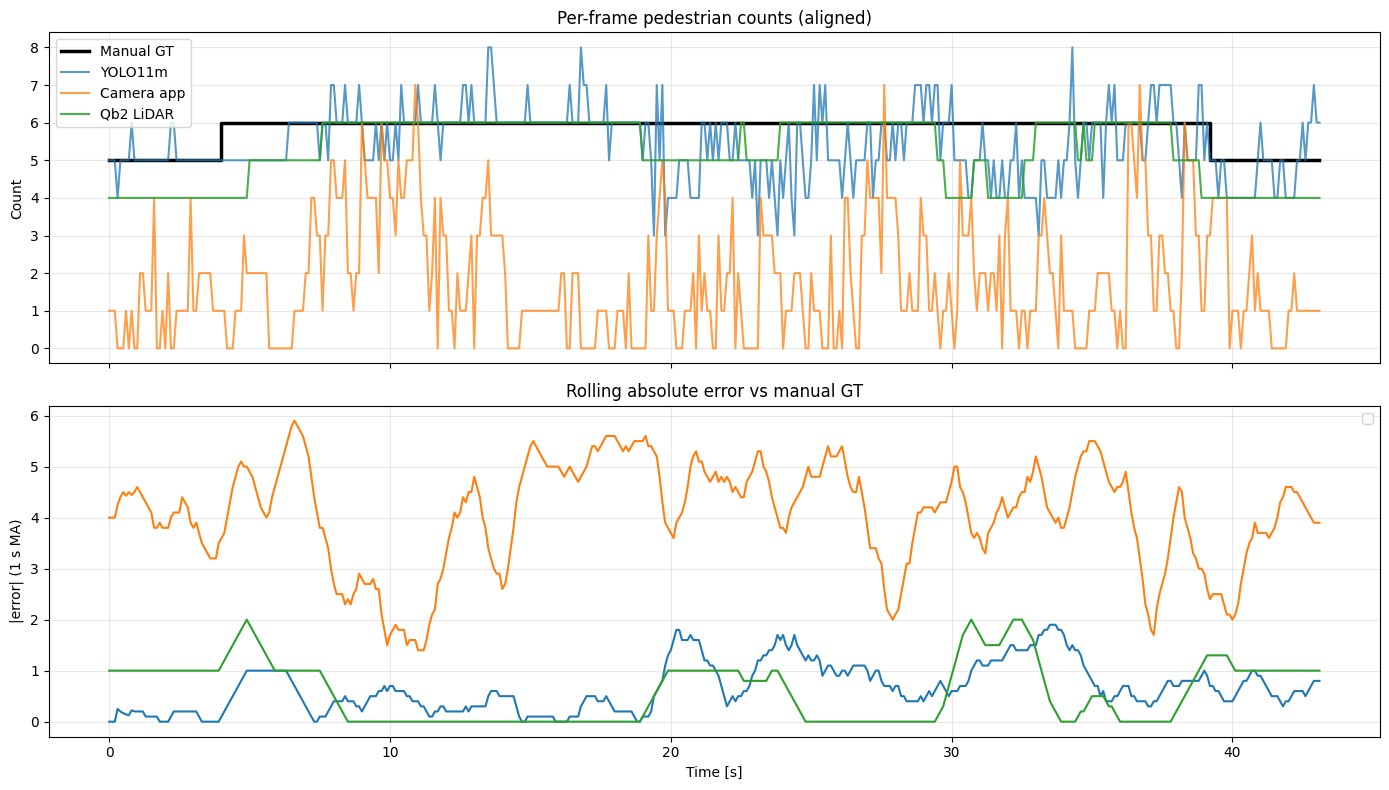

In [26]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

axes[0].step(df.t, df.manual_gt, where="post", label="Manual GT",
             lw=2.5, color="black")
axes[0].plot(df.t, df.yolo,   label="YOLO11m",    alpha=.75)
axes[0].plot(df.t, df.camera, label="Camera app", alpha=.75)
axes[0].plot(df.t, df.lidar,  label="Qb2 LiDAR",  alpha=.85)
axes[0].set_ylabel("Count")
axes[0].set_title("Per-frame pedestrian counts (aligned)")
axes[0].legend(); axes[0].grid(alpha=.3)

err = pd.DataFrame({
    "YOLO":   np.abs(df.yolo   - df.manual_gt),
    "Camera": np.abs(df.camera - df.manual_gt),
    "LiDAR":  np.abs(df.lidar  - df.manual_gt),
})
axes[1].plot(df.t, err.rolling(GRID_HZ, min_periods=1).mean())
axes[1].set_xlabel("Time [s]"); axes[1].set_ylabel("|error| (1 s MA)")
axes[1].set_title("Rolling absolute error vs manual GT")
axes[1].legend(); axes[1].grid(alpha=.3)
plt.tight_layout()
plt.savefig(f"{CONFIG['out_dir']}/timeseries.png", dpi=150)
plt.show()

In [27]:
# ============================================================
# 7.1 Inputs / target
# ============================================================
X_cam  = df.camera.values.astype(float)
X_lid  = df.lidar.values.astype(float)
X_yolo = df.yolo.values.astype(float)
y      = df.manual_gt.values.astype(float)
N      = len(y)
print(f"N = {N} samples on the {GRID_HZ} Hz grid")

# Optional per-source confidence: mean YOLO box confidence per frame
conf_yolo = np.array([
    (np.mean([d["conf"] for d in r["detections"]]) if r["detections"] else 0.0)
    for r in yolo_records
])
# Resample confidence to grid
ts_yolo = np.array([r["t"] for r in yolo_records])
idx = np.clip(np.searchsorted(ts_yolo, t_grid), 1, len(ts_yolo) - 1)
conf_yolo_grid = conf_yolo[idx]

# ============================================================
# 7.2 Blocked cross-validation (contiguous time blocks)
# ============================================================
def blocked_cv_indices(N, k):
    """Return list of (train_idx, test_idx) with contiguous test blocks."""
    bounds = np.linspace(0, N, k + 1).astype(int)
    folds = []
    for i in range(k):
        test = np.arange(bounds[i], bounds[i + 1])
        train = np.setdiff1d(np.arange(N), test)
        folds.append((train, test))
    return folds

folds = blocked_cv_indices(N, CONFIG["cv_folds"])
print(f"{len(folds)} blocked folds created")

# ============================================================
# 7.3 Ensemble definitions
# ============================================================
def fit_weights_wavg(Xtr, ytr):
    """Least-squares non-negative weights (clipped)."""
    from scipy.optimize import nnls
    A = np.column_stack([Xtr[:, 0], Xtr[:, 1], Xtr[:, 2]])
    w, _ = nnls(A, ytr)
    if w.sum() == 0:
        w = np.ones(3)
    return w / w.sum()

def bin_class(c):
    """Map a count to a discrete class for majority voting."""
    if c <= 1:   return 0     # empty / single
    if c <= 3:   return 1     # low
    if c <= 5:   return 2     # medium
    return 3                  # high

BIN_CENTERS = [0.5, 2.0, 4.0, 6.5]

def majority_vote(xc, xl, xy):
    votes = np.array([[bin_class(xc[i]), bin_class(xl[i]), bin_class(xy[i])]
                      for i in range(len(xc))])
    from scipy.stats import mode
    cls = mode(votes, axis=1, keepdims=False).mode
    return np.array([BIN_CENTERS[c] for c in cls], dtype=float)

ENSEMBLES = {
    "Mean":           lambda Xtr, ytr, Xte: Xte.mean(axis=1),
    "Median":         lambda Xtr, ytr, Xte: np.median(Xte, axis=1),
    "Trimmed mean":   lambda Xtr, ytr, Xte: (Xte.sum(1) - Xte.max(1) - Xte.min(1)),
    "WAvg (learned)": lambda Xtr, ytr, Xte: Xte @ fit_weights_wavg(Xtr, ytr),
    "Stack-LinReg":   lambda Xtr, ytr, Xte: LinearRegression().fit(Xtr, ytr).predict(Xte),
    "Stack-GBT":      lambda Xtr, ytr, Xte: GradientBoostingRegressor(
                          max_depth=2, n_estimators=200, random_state=0
                      ).fit(Xtr, ytr).predict(Xte),
    "Majority vote":  lambda Xtr, ytr, Xte: majority_vote(Xte[:, 0], Xte[:, 1], Xte[:, 2]),
}

# Add a confidence-aware ensemble
def conf_aware(Xtr, ytr, Xte, conf_tr, conf_te):
    """Trust LiDAR when YOLO confidence is low, else trust YOLO."""
    w_yolo = conf_te
    w_lid  = 1 - conf_te
    w_cam  = np.full_like(w_lid, 0.20)
    W = np.column_stack([w_cam, w_lid, w_yolo])
    W = W / W.sum(1, keepdims=True)
    return (Xte * W).sum(1)

def stack_with_conf(Xtr, ytr, Xte):
    # Xte here is [cam, lidar, yolo, conf_yolo]
    return GradientBoostingRegressor(
        max_depth=3, n_estimators=200, random_state=0
    ).fit(Xtr, ytr).predict(Xte)

# ============================================================
# 7.4 Evaluate every ensemble with blocked CV
# ============================================================
results = {name: {"mae": [], "rmse": []} for name in ENSEMBLES}
results["Conf-aware GBT"] = {"mae": [], "rmse": []}
# also record each single-source baseline
results["Camera only"] = {"mae": [], "rmse": []}
results["LiDAR only"]  = {"mae": [], "rmse": []}
results["YOLO only"]   = {"mae": [], "rmse": []}

for tr, te in folds:
    X3_tr = np.column_stack([X_cam[tr], X_lid[tr], X_yolo[tr]])
    X3_te = np.column_stack([X_cam[te], X_lid[te], X_yolo[te]])
    y_tr, y_te = y[tr], y[te]

    for name, fn in ENSEMBLES.items():
        yhat = fn(X3_tr, y_tr, X3_te)
        results[name]["mae"].append(mean_absolute_error(y_te, yhat))
        results[name]["rmse"].append(np.sqrt(mean_squared_error(y_te, yhat)))

    # confidence-aware (needs 4th column)
    X4_tr = np.column_stack([X_cam[tr], X_lid[tr], X_yolo[tr], conf_yolo_grid[tr]])
    X4_te = np.column_stack([X_cam[te], X_lid[te], X_yolo[te], conf_yolo_grid[te]])
    yhat = stack_with_conf(X4_tr, y_tr, X4_te)
    results["Conf-aware GBT"]["mae"].append(mean_absolute_error(y_te, yhat))
    results["Conf-aware GBT"]["rmse"].append(np.sqrt(mean_squared_error(y_te, yhat)))

    # single-source baselines
    for label, arr in [("Camera only", X_cam), ("LiDAR only", X_lid), ("YOLO only", X_yolo)]:
        yhat = arr[te]
        results[label]["mae"].append(mean_absolute_error(y_te, yhat))
        results[label]["rmse"].append(np.sqrt(mean_squared_error(y_te, yhat)))

# ============================================================
# 7.5 Final results table
# ============================================================
rows = []
for name, d in results.items():
    rows.append({
        "Method": name,
        "MAE":  np.mean(d["mae"]),
        "MAE std": np.std(d["mae"]),
        "RMSE": np.mean(d["rmse"]),
    })
table = pd.DataFrame(rows).sort_values("MAE").reset_index(drop=True)
table.to_csv(f"{CONFIG['out_dir']}/ensemble_results.csv", index=False)
print(table.to_string(index=False))

N = 432 samples on the 10 Hz grid
5 blocked folds created
        Method      MAE  MAE std     RMSE
     Stack-GBT 0.165715 0.117751 0.257938
Conf-aware GBT 0.198570 0.130417 0.330923
  Stack-LinReg 0.250492 0.101217 0.304136
    LiDAR only 0.583160 0.328001 0.764491
WAvg (learned) 0.611424 0.265723 0.759217
     YOLO only 0.670730 0.291957 0.932785
        Median 0.821411 0.373911 1.028412
  Trimmed mean 0.821411 0.373911 1.028412
          Mean 1.680816 0.292153 1.793474
 Majority vote 1.918752 0.710488 2.414798
   Camera only 4.052339 0.425015 4.320381


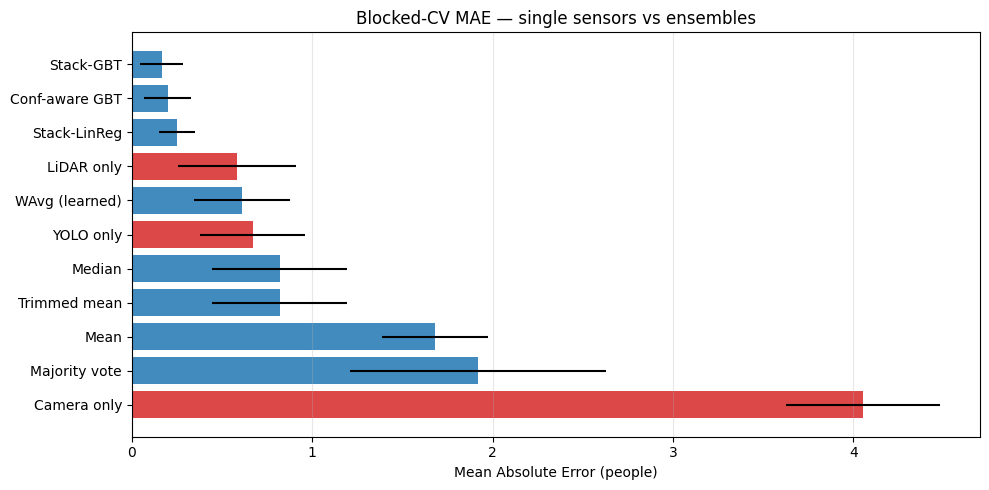

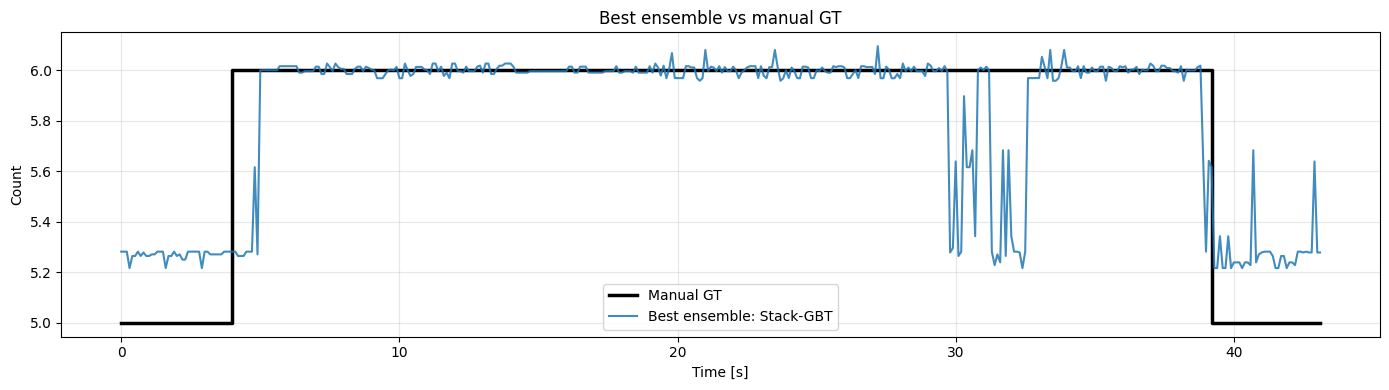


Best ensemble: Stack-GBT  |  MAE = 0.166 people


In [28]:
# ============================================================
# 8.1 Bar chart of MAE per method
# ============================================================
fig, ax = plt.subplots(figsize=(10, 5))
colors = ["#d62728" if "only" in m else "#1f77b4" for m in table.Method]
ax.barh(table.Method, table.MAE, xerr=table["MAE std"], color=colors, alpha=.85)
ax.set_xlabel("Mean Absolute Error (people)")
ax.set_title("Blocked-CV MAE — single sensors vs ensembles")
ax.invert_yaxis(); ax.grid(axis="x", alpha=.3)
plt.tight_layout()
plt.savefig(f"{CONFIG['out_dir']}/mae_bar.png", dpi=150)
plt.show()

# ============================================================
# 8.2 Best ensemble — per-frame overlay
# ============================================================
best_name = table.Method.iloc[0]
if best_name in ENSEMBLES:
    X3 = np.column_stack([X_cam, X_lid, X_yolo])
    yhat_best = ENSEMBLES[best_name](X3, y, X3)
else:
    X4 = np.column_stack([X_cam, X_lid, X_yolo, conf_yolo_grid])
    yhat_best = stack_with_conf(X4, y, X4)

plt.figure(figsize=(14, 4))
plt.step(df.t, df.manual_gt, where="post", color="black", lw=2.5, label="Manual GT")
plt.plot(df.t, yhat_best, label=f"Best ensemble: {best_name}", alpha=.85)
plt.xlabel("Time [s]"); plt.ylabel("Count")
plt.title("Best ensemble vs manual GT")
plt.legend(); plt.grid(alpha=.3)
plt.tight_layout()
plt.savefig(f"{CONFIG['out_dir']}/best_ensemble_trace.png", dpi=150)
plt.show()

print(f"\nBest ensemble: {best_name}  |  MAE = {table.MAE.iloc[0]:.3f} people")

In [29]:
# ============================================================
# 9.1 Auto-generated LaTeX-ready summary
# ============================================================
lines = []
lines.append("\\begin{table}[h]")
lines.append("\\centering")
lines.append("\\caption{Pedestrian counting — blocked cross-validation MAE.}")
lines.append("\\begin{tabular}{lcc}")
lines.append("\\hline")
lines.append("Method & MAE (people) & RMSE (people) \\\\")
lines.append("\\hline")
for _, r in table.iterrows():
    lines.append(f"{r['Method']} & {r['MAE']:.3f} $\\pm$ {r['MAE std']:.3f} & {r['RMSE']:.3f} \\\\")
lines.append("\\hline")
lines.append("\\end{tabular}")
lines.append("\\end{table}")
report = "\n".join(lines)
with open(f"{CONFIG['out_dir']}/results_table.tex", "w") as f:
    f.write(report)
print(report)

\begin{table}[h]
\centering
\caption{Pedestrian counting — blocked cross-validation MAE.}
\begin{tabular}{lcc}
\hline
Method & MAE (people) & RMSE (people) \\
\hline
Stack-GBT & 0.166 $\pm$ 0.118 & 0.258 \\
Conf-aware GBT & 0.199 $\pm$ 0.130 & 0.331 \\
Stack-LinReg & 0.250 $\pm$ 0.101 & 0.304 \\
LiDAR only & 0.583 $\pm$ 0.328 & 0.764 \\
WAvg (learned) & 0.611 $\pm$ 0.266 & 0.759 \\
YOLO only & 0.671 $\pm$ 0.292 & 0.933 \\
Median & 0.821 $\pm$ 0.374 & 1.028 \\
Trimmed mean & 0.821 $\pm$ 0.374 & 1.028 \\
Mean & 1.681 $\pm$ 0.292 & 1.793 \\
Majority vote & 1.919 $\pm$ 0.710 & 2.415 \\
Camera only & 4.052 $\pm$ 0.425 & 4.320 \\
\hline
\end{tabular}
\end{table}


In [30]:
# ============================================================
# 10.1 Recompute per-frame fused count (best ensemble)
# ============================================================
X3 = np.column_stack([X_cam, X_lid, X_yolo])
X4 = np.column_stack([X_cam, X_lid, X_yolo, conf_yolo_grid])

if best_name in ENSEMBLES:
    fused_all = ENSEMBLES[best_name](X3, y, X3)
else:
    fused_all = stack_with_conf(X4, y, X4)

# One fused value per grid step; snap each camera frame to nearest grid index
def to_grid_idx(t):
    return int(np.clip(round(t * GRID_HZ), 0, len(t_grid) - 1))

print(f"Fused signal ready ({best_name}), N={len(fused_all)}")

# ============================================================
# 10.2 Index YOLO detections by frame for O(1) lookup
# ============================================================
yolo_by_frame = {r["frame"]: r["detections"] for r in yolo_records}

# ============================================================
# 10.3 Video writer
# ============================================================
cap = cv2.VideoCapture(CONFIG["video_path"])
W  = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
H  = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

out_path = f"{CONFIG['out_dir']}/fusion_demo.mp4"
fourcc   = cv2.VideoWriter_fourcc(*"mp4v")
writer   = cv2.VideoWriter(out_path, fourcc, fps, (W, H))
print(f"Writing {out_path} @ {fps:.2f} fps, {W}x{H}")

# ============================================================
# 10.4 Draw helpers
# ============================================================
COLOR_YOLO   = (  0, 255,   0)   # green
COLOR_CAM    = (255, 128,   0)   # blue-ish
COLOR_LIDAR  = (  0, 165, 255)   # orange
COLOR_FUSED  = (  0,   0, 255)   # red
COLOR_GT     = (255, 255, 255)   # white
COLOR_BOX    = (  0, 255,   0)   # green boxes

# Small sparkline canvas
SPARK_W, SPARK_H = 420, 120
SPARK_MARGIN     = 14
SPARK_PAD        = 8

def draw_sparkline(canvas, t_now, hist_len_s=8.0):
    """Tiny time-series panel in the top-right corner."""
    x0 = SPARK_W + SPARK_MARGIN * 2
    y0 = SPARK_MARGIN * 2

    # Background panel
    cv2.rectangle(canvas,
                  (SPARK_MARGIN, SPARK_MARGIN),
                  (SPARK_MARGIN + SPARK_W + SPARK_PAD * 2,
                   SPARK_MARGIN + SPARK_H + SPARK_PAD * 2),
                  (20, 20, 20), -1)
    cv2.rectangle(canvas,
                  (SPARK_MARGIN, SPARK_MARGIN),
                  (SPARK_MARGIN + SPARK_W + SPARK_PAD * 2,
                   SPARK_MARGIN + SPARK_H + SPARK_PAD * 2),
                  (100, 100, 100), 1)

    # Window of history
    i_now = to_grid_idx(t_now)
    i0    = max(0, i_now - int(hist_len_s * GRID_HZ))
    if i_now - i0 < 2:
        return
    ts   = t_grid[i0:i_now]
    xs   = (ts - ts[0]) / max(ts[-1] - ts[0], 1e-6)
    px   = (SPARK_MARGIN + SPARK_PAD + xs * SPARK_W).astype(int)

    max_c = max(6, int(max(y[i0:i_now].max(),
                           fused_all[i0:i_now].max(),
                           X_yolo[i0:i_now].max()) + 1))

    def to_py(vals):
        return (SPARK_MARGIN + SPARK_PAD + SPARK_H
                - (np.asarray(vals) / max_c) * SPARK_H).astype(int)

    def plot(series, color, label):
        py = to_py(series)
        for k in range(1, len(px)):
            cv2.line(canvas, (px[k - 1], py[k - 1]), (px[k], py[k]),
                     color, 2, cv2.LINE_AA)
        cv2.putText(canvas, label,
                    (SPARK_MARGIN + SPARK_PAD + 4,
                     SPARK_MARGIN + SPARK_PAD + 12 + 14 * _next_legend_y()),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.42, color, 1, cv2.LINE_AA)

    _reset_legend()
    plot(y[i0:i_now],         COLOR_GT,    "GT")
    plot(fused_all[i0:i_now], COLOR_FUSED, f"Fused ({best_name})")
    plot(X_yolo[i0:i_now],    COLOR_YOLO,  "YOLO")
    plot(X_lid[i0:i_now],     COLOR_LIDAR, "LiDAR")
    plot(X_cam[i0:i_now],     COLOR_CAM,   "Camera")

# legend y-index helper
_legend_counter = [0]
def _reset_legend(): _legend_counter[0] = 0
def _next_legend_y():
    _legend_counter[0] += 1
    return _legend_counter[0]

def draw_hud(canvas, t_now):
    """Numeric HUD in the bottom-left."""
    i = to_grid_idx(t_now)
    fused_v = fused_all[i]
    lines = [
        (f"t = {t_now:5.2f}s", (255, 255, 255)),
        (f"GT          : {y[i]:.1f}",         COLOR_GT),
        (f"YOLO11m     : {X_yolo[i]:.0f}",    COLOR_YOLO),
        (f"LiDAR Qb2   : {X_lid[i]:.0f}",     COLOR_LIDAR),
        (f"Camera app  : {X_cam[i]:.0f}",     COLOR_CAM),
        (f"FUSED  ->   : {fused_v:.1f}",      COLOR_FUSED),
    ]
    y0 = H - 20 - 22 * (len(lines) - 1)
    for k, (txt, col) in enumerate(lines):
        cv2.putText(canvas, txt, (20, y0 + 22 * k),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.65, (0, 0, 0), 4, cv2.LINE_AA)
        cv2.putText(canvas, txt, (20, y0 + 22 * k),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.65, col, 1, cv2.LINE_AA)

def draw_yolo_boxes(canvas, frame_idx):
    for d in yolo_by_frame.get(frame_idx, []):
        x1, y1, x2, y2 = d["box"]
        cv2.rectangle(canvas, (x1, y1), (x2, y2), COLOR_BOX, 2)
        cv2.putText(canvas, f"{d['conf']:.2f}", (x1, max(0, y1 - 6)),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, COLOR_BOX, 1, cv2.LINE_AA)

def draw_roi(canvas):
    cv2.polylines(canvas, [roi_px.astype(int)], True, (0, 255, 255), 2)

def draw_phase_label(canvas, t_now):
    """Which manual-GT segment are we in?"""
    for s, e, c in gt_segments:
        if s <= t_now < e:
            txt = f"GT phase: {c} people  ({s:.1f}–{e:.1f}s)"
            (tw, th), _ = cv2.getTextSize(txt, cv2.FONT_HERSHEY_SIMPLEX, 0.6, 2)
            cv2.rectangle(canvas, (W//2 - tw//2 - 8, 20),
                          (W//2 + tw//2 + 8, 20 + th + 12), (0, 0, 0), -1)
            cv2.putText(canvas, txt, (W//2 - tw//2, 20 + th + 4),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 255), 2, cv2.LINE_AA)
            return

# ============================================================
# 10.5 Render frames
# ============================================================
frame_idx = 0
while True:
    ok, frame = cap.read()
    if not ok:
        break
    t_now = frame_idx / fps

    overlay = frame.copy()
    draw_roi(overlay)
    draw_yolo_boxes(overlay, frame_idx)
    draw_hud(overlay, t_now)
    # draw_sparkline(overlay, t_now)
    draw_phase_label(overlay, t_now)

    writer.write(overlay)

    if frame_idx % 60 == 0:
        print(f"  frame {frame_idx}/{total_frames} (t={t_now:.1f}s)")
    frame_idx += 1

cap.release()
writer.release()
print(f"Done → {out_path}")

Fused signal ready (Stack-GBT), N=432
Writing /content/drive/My Drive/Crowd-Density-Monitoring/Code/baseline/outputs/fusion_demo.mp4 @ 10.52 fps, 1024x576
  frame 0/454 (t=0.0s)
  frame 60/454 (t=5.7s)
  frame 120/454 (t=11.4s)
  frame 180/454 (t=17.1s)
  frame 240/454 (t=22.8s)
  frame 300/454 (t=28.5s)
  frame 360/454 (t=34.2s)
  frame 420/454 (t=39.9s)
Done → /content/drive/My Drive/Crowd-Density-Monitoring/Code/baseline/outputs/fusion_demo.mp4


In [32]:
# ============================================================
# Extra counting metrics: MAE, RMSE, Bias, Exact-match
# (run after df has manual_gt / camera / yolo / lidar columns)
# ============================================================
def counting_metrics(pred, gt):
    pred = np.asarray(pred, dtype=float)
    gt   = np.asarray(gt,   dtype=float)
    err  = pred - gt

    tp = np.minimum(pred, gt).sum()
    fp = np.maximum(pred - gt, 0).sum()
    fn = np.maximum(gt - pred, 0).sum()
    P  = tp / (tp + fp) if tp + fp else 0
    R  = tp / (tp + fn) if tp + fn else 0
    F  = 2 * P * R / (P + R) if P + R else 0

    return {
        "Precision":   100 * P,
        "Recall":      100 * R,
        "F1 Score":    100 * F,
        "MAE":         np.abs(err).mean(),
        "RMSE":        np.sqrt((err ** 2).mean()),
        "Bias":        err.mean(),          # + over-count, - under-count
        "Exact %":     100 * np.mean(err == 0),
        "Within ±1 %": 100 * np.mean(np.abs(err) <= 1),
    }

methods = {
    "Camera app": df["camera"].values,
    "YOLO":       df["yolo"].values,
    "LiDAR":      df["lidar"].values,
}

rows = []
for name, pred in methods.items():
    m = counting_metrics(pred, df["manual_gt"].values)
    rows.append({"Method": name, **m})

metrics_table = pd.DataFrame(rows).round(2)
print(metrics_table.to_string(index=False))

metrics_table.to_csv(f"{CONFIG['out_dir']}/extra_counting_metrics.csv", index=False)

    Method  Precision  Recall  F1 Score  MAE  RMSE  Bias  Exact %  Within ±1 %
Camera app      99.61   30.41     46.60 4.05  4.34 -4.04     1.39         8.56
      YOLO      97.48   90.80     94.02 0.67  0.98 -0.40    45.83        88.43
     LiDAR     100.00   89.97     94.72 0.58  0.87 -0.58    50.00        91.67


In [33]:
# ============================================================
# Efficiency metrics: Mean Latency (ms/frame), GFLOPs/frame, RAM (MB)
# ============================================================
import time, psutil
proc = psutil.Process(os.getpid())

efficiency_rows = []

# ---------------------------------------------------------
# 1) YOLO — measured on the same frames already processed
# ---------------------------------------------------------
try:
    gflops_yolo = model.info(verbose=False)[3]   # (layers, params, gradients, GFLOPs)
except Exception:
    gflops_yolo = None   # fall back to N/A if ultralytics version differs

cap = cv2.VideoCapture(CONFIG["video_path"])
lat_yolo, ram_yolo = [], []
while True:
    ok, frame = cap.read()
    if not ok:
        break
    rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    t0 = time.perf_counter()
    _ = model(rgb, conf=CONFIG["yolo_conf"], imgsz=CONFIG["yolo_imgsz"], verbose=False)
    lat_yolo.append(time.perf_counter() - t0)
    ram_yolo.append(proc.memory_info().rss / 1e6)
cap.release()

efficiency_rows.append({
    "Method": "YOLO",
    "Mean Latency ms/frame": 1000 * np.mean(lat_yolo),
    "GFLOPs/frame": gflops_yolo if gflops_yolo is not None else "N/A",
    "RAM in MB/frame": np.max(ram_yolo),
})

# ---------------------------------------------------------
# 2) LiDAR — measured on the same pipeline used for counting
#    (excludes disk I/O, same convention as the Qb2 notebook)
# ---------------------------------------------------------
tracker_bench = SimpleTracker()
lat_lidar, ram_lidar = [], []
for path in frame_files:
    _, _, xyz = load_frame_pb(path)          # I/O excluded from timing
    t0 = time.perf_counter()
    dets = cluster_pedestrians(filter_points(xyz))
    _ = tracker_bench.update(dets)
    lat_lidar.append(time.perf_counter() - t0)
    ram_lidar.append(proc.memory_info().rss / 1e6)

efficiency_rows.append({
    "Method": "LiDAR",
    "Mean Latency ms/frame": 1000 * np.mean(lat_lidar),
    "GFLOPs/frame": "N/A (non-NN)",
    "RAM in MB/frame": np.max(ram_lidar),
})

# ---------------------------------------------------------
# 3) Camera app — cannot be benchmarked: only the precomputed
#    detection_counts.json is available, not the app's own
#    inference code. Report as N/A / closed-source.
# ---------------------------------------------------------
efficiency_rows.append({
    "Method": "Camera app",
    "Mean Latency ms/frame": "N/A (closed-source, precomputed)",
    "GFLOPs/frame": "N/A (closed-source)",
    "RAM in MB/frame": "N/A (closed-source)",
})

efficiency_table = pd.DataFrame(efficiency_rows)
print(efficiency_table.to_string(index=False))
efficiency_table.to_csv(f"{CONFIG['out_dir']}/efficiency_metrics.csv", index=False)

# ---------------------------------------------------------
# Merge with the accuracy table (Precision/Recall/F1/MAE/RMSE)
# into the single table for the paper
# ---------------------------------------------------------
paper_table = metrics_table.merge(efficiency_table, on="Method", how="left")
print("\nFinal paper table:")
print(paper_table.to_string(index=False))
paper_table.to_csv(f"{CONFIG['out_dir']}/paper_table_full.csv", index=False)

    Method            Mean Latency ms/frame        GFLOPs/frame     RAM in MB/frame
      YOLO                       925.260932                 N/A         1102.413824
     LiDAR                        18.448312        N/A (non-NN)         1049.079808
Camera app N/A (closed-source, precomputed) N/A (closed-source) N/A (closed-source)

Final paper table:
    Method  Precision  Recall  F1 Score  MAE  RMSE  Bias  Exact %  Within ±1 %            Mean Latency ms/frame        GFLOPs/frame     RAM in MB/frame
Camera app      99.61   30.41     46.60 4.05  4.34 -4.04     1.39         8.56 N/A (closed-source, precomputed) N/A (closed-source) N/A (closed-source)
      YOLO      97.48   90.80     94.02 0.67  0.98 -0.40    45.83        88.43                       925.260932                 N/A         1102.413824
     LiDAR     100.00   89.97     94.72 0.58  0.87 -0.58    50.00        91.67                        18.448312        N/A (non-NN)         1049.079808
